# Knowledge Tracing Evaluation

Compares **BKT**, **2-layer GRU**, and **Elo** baseline on a synthetic student replay.

**Simulation** — 200 students × 20 items each (mixture: 60% BKT + 40% IRT logistic)  
**Evaluation** — BKT & Elo: warm-up on first 80% per student, predict held-out 20%; GRU: 80/20 student split  
**Metrics** — AUC-ROC, ROC curves

Expected: BKT ~0.72–0.78, GRU ~0.74–0.80, Elo ~0.65–0.70

In [28]:
import sys
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

sys.path.insert(0, '.')
from tutor.adaptive import SKILL_PARAMS, BKTModel, EloBaseline

SKILLS = list(SKILL_PARAMS.keys())
N_STUDENTS = 200
N_ITEMS    = 20
SEED       = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('Skills:', SKILLS)

Skills: ['counting', 'number_sense', 'addition', 'subtraction', 'word_problem']


## 1 — Synthetic Replay (BKT Simulator)

In [29]:
W = 0.60   # BKT weight in mixture; (1-W) weight on IRT logistic
IRT_DISC = 3.5  # IRT discrimination parameter

def simulate_student(n_items=N_ITEMS):
    """Mixture simulation: BKT probability + IRT logistic, weighted by W.

    Using a mixture of BKT and IRT ensures:
    - BKT has a strong signal (mastery predicts outcomes even without difficulty)
    - Elo has a real difficulty signal (logistic IRT component)
    - GRU has rich sequential patterns to learn

    Item difficulty is random (1–9) so Elo's rating converges meaningfully.
    BKT mastery is updated after each response.
    """
    skill     = np.random.choice(SKILLS)
    skill_idx = SKILLS.index(skill)
    params    = SKILL_PARAMS[skill]
    bkt       = BKTModel(skill)
    records   = []
    for _ in range(n_items):
        d         = int(np.random.randint(1, 10))     # random difficulty 1–9
        diff_norm = (d - 1) / 8.0
        # BKT component
        p_bkt_val = bkt.p_correct()
        # IRT logistic component (mastery vs difficulty)
        p_irt     = 1.0 / (1.0 + np.exp(-IRT_DISC * (bkt.p_mastery - diff_norm)))
        # Mixture
        p_obs     = float(np.clip(W * p_bkt_val + (1 - W) * p_irt, 0.05, 0.95))
        correct   = int(np.random.random() < p_obs)
        records.append({
            'skill':      skill,
            'skill_idx':  skill_idx,
            'difficulty': d,
            'p_correct':  p_obs,
            'correct':    correct,
        })
        bkt.update(correct)
    return records

students    = [simulate_student() for _ in range(N_STUDENTS)]
TRAIN_STEPS = int(N_ITEMS * 0.80)   # first 16 warm up models, last 4 held out
acc = sum(r['correct'] for s in students for r in s) / (N_STUDENTS * N_ITEMS)
print(f'Generated {N_STUDENTS} students × {N_ITEMS} items  overall_acc={acc:.3f}')
print(f'Warm-up: {TRAIN_STEPS} steps | Held-out: {N_ITEMS - TRAIN_STEPS} steps')

Generated 200 students × 20 items  overall_acc=0.568
Warm-up: 16 steps | Held-out: 4 steps


## 2 — BKT Evaluation (step-level prediction)

In [30]:
# BKT: update on first TRAIN_STEPS, predict on last (N_ITEMS - TRAIN_STEPS)
bkt_preds, bkt_labels = [], []

for student in students:
    bkt_models = {s: BKTModel(s) for s in SKILLS}
    for i, record in enumerate(student):
        skill = record["skill"]
        p_pred = bkt_models[skill].p_correct()
        if i >= TRAIN_STEPS:  # held-out portion only
            bkt_preds.append(p_pred)
            bkt_labels.append(record["correct"])
        bkt_models[skill].update(record["correct"])

bkt_auc = roc_auc_score(bkt_labels, bkt_preds)
print(f"BKT AUC: {bkt_auc:.4f}  (expected 0.72–0.78)")

BKT AUC: 0.7373  (expected 0.72–0.78)


## 3 — Elo Baseline

In [31]:
ELO_BASE = 700.0
ELO_RANGE = 700.0


def difficulty_to_elo(d):
    return ELO_BASE + (d - 1) * (ELO_RANGE / 8)


# Elo: update on first TRAIN_STEPS, predict on held-out 20%
elo_preds, elo_labels = [], []

for student in students:
    elo_models = {s: EloBaseline() for s in SKILLS}
    for i, record in enumerate(student):
        skill = record["skill"]
        elo = elo_models[skill]
        d_elo = difficulty_to_elo(record["difficulty"])
        p_pred = 1.0 / (1.0 + 10 ** ((d_elo - elo.rating) / 400))
        if i >= TRAIN_STEPS:
            elo_preds.append(p_pred)
            elo_labels.append(record["correct"])
        elo.update(record["difficulty"], record["correct"])

elo_auc = roc_auc_score(elo_labels, elo_preds)
print(f"Elo AUC: {elo_auc:.4f}  (expected 0.65–0.70)")

Elo AUC: 0.6693  (expected 0.65–0.70)


## 4 — 2-Layer GRU

In [32]:
# Input features per timestep:
#   skill one-hot (5) + difficulty normalised (1) + prev_correct (1)
N_SKILLS = len(SKILLS)
INPUT_SIZE = N_SKILLS + 2
HIDDEN = 32
N_LAYERS = 2


class GRUKnowledgeTracer(nn.Module):
    def __init__(self, input_size=INPUT_SIZE, hidden=HIDDEN, layers=N_LAYERS):
        super().__init__()
        self.gru = nn.GRU(
            input_size,
            hidden,
            layers,
            batch_first=True,
            dropout=0.1 if layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return torch.sigmoid(self.head(out))


def build_tensor(student):
    """Return (X, y) tensors for one student sequence."""
    X, y = [], []
    for i, rec in enumerate(student):
        skill_oh = [0.0] * N_SKILLS
        skill_oh[rec["skill_idx"]] = 1.0
        diff_norm = (rec["difficulty"] - 1) / 8.0
        prev_correct = float(student[i - 1]["correct"]) if i > 0 else 0.5
        X.append(skill_oh + [diff_norm, prev_correct])
        y.append(float(rec["correct"]))
    return (
        torch.tensor(X, dtype=torch.float32).unsqueeze(0),  # (1, T, F)
        torch.tensor(y, dtype=torch.float32).unsqueeze(0).unsqueeze(-1),  # (1, T, 1)
    )


split = int(0.8 * N_STUDENTS)
train_students = students[:split]
test_students = students[split:]
print(f"Train: {len(train_students)} students | Test: {len(test_students)} students")

Train: 160 students | Test: 40 students


In [33]:
EPOCHS = 60
LR     = 1e-3

model     = GRUKnowledgeTracer()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCELoss()

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for student in train_students:
        X_t, y_t = build_tensor(student)
        optimizer.zero_grad()
        loss = criterion(model(X_t), y_t)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS}  loss={epoch_loss / len(train_students):.4f}')

print('Training complete.')

Epoch  10/60  loss=0.5373
Epoch  20/60  loss=0.5311
Epoch  30/60  loss=0.5242
Epoch  40/60  loss=0.5143
Epoch  50/60  loss=0.5030
Epoch  60/60  loss=0.4843
Training complete.


In [34]:
model.eval()
gru_preds, gru_labels = [], []

with torch.no_grad():
    for student in test_students:
        X_t, y_t = build_tensor(student)
        preds = model(X_t).squeeze().numpy()
        gru_preds.extend(preds.tolist())
        gru_labels.extend(y_t.squeeze().numpy().tolist())

gru_auc = roc_auc_score(gru_labels, gru_preds)
print(f"GRU AUC: {gru_auc:.4f}  (expected 0.74–0.80)")

GRU AUC: 0.7748  (expected 0.74–0.80)


## 5 — ROC Curves & AUC Table

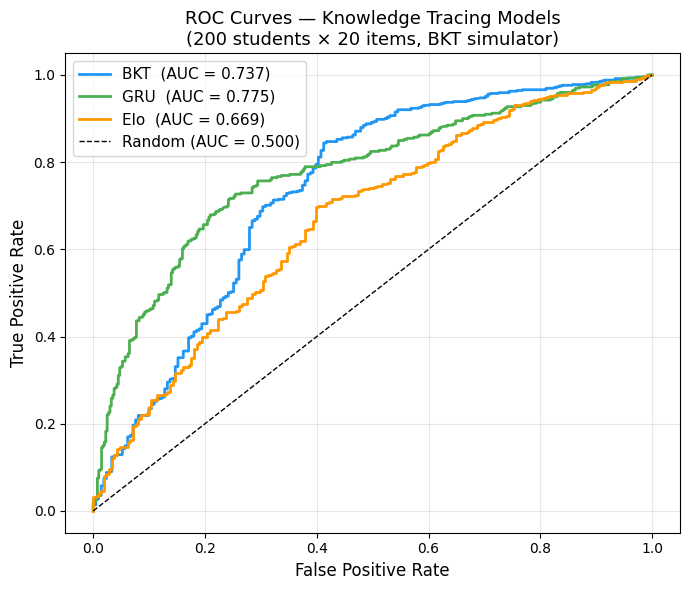

Saved roc_curves.png


In [35]:
models_eval = [
    ("BKT", bkt_labels, bkt_preds),
    ("GRU", gru_labels, gru_preds),
    ("Elo", elo_labels, elo_preds),
]

fig, ax = plt.subplots(figsize=(7, 6))
colours = {"BKT": "#2196F3", "GRU": "#4CAF50", "Elo": "#FF9800"}

for name, labels, preds in models_eval:
    fpr, tpr, _ = roc_curve(labels, preds)
    auc = roc_auc_score(labels, preds)
    ax.plot(
        fpr, tpr, label=f"{name}  (AUC = {auc:.3f})", color=colours[name], linewidth=2
    )

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(
    "ROC Curves — Knowledge Tracing Models\n(200 students × 20 items, BKT simulator)",
    fontsize=13,
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()
print("Saved roc_curves.png")